In [1]:
import warnings
warnings.filterwarnings("ignore")

In [2]:
# Step 1: import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

In [3]:
divider = f"\n{"*" * 90}\n"

# Step 2: Prepare the data set
data = {
    "PointID": [x for x in range(1, 5)],
    "Feature1(X)": [1.0, np.nan, 5.0, 8.0],
    "Feature2(Y)": [2.0, 1.8, np.nan, 8.0]
}

df = pd.DataFrame(data)
print(df)

   PointID  Feature1(X)  Feature2(Y)
0        1          1.0          2.0
1        2          NaN          1.8
2        3          5.0          NaN
3        4          8.0          8.0


In [4]:
# Treating missing values
df["Feature1(X)"] = df["Feature1(X)"].fillna(df["Feature1(X)"].mean())
df["Feature2(Y)"] = df["Feature2(Y)"].fillna(df["Feature2(Y)"].mean())
print(df)

   PointID  Feature1(X)  Feature2(Y)
0        1     1.000000     2.000000
1        2     4.666667     1.800000
2        3     5.000000     3.933333
3        4     8.000000     8.000000


In [5]:
# Step 3: Initialize the K-Means Model
kmeans = KMeans(n_clusters=2, random_state=0)

# Step 4: Fit the Model to the Data
kmeans.fit(df)

,n_clusters,2
,init,'k-means++'
,n_init,'auto'
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,0
,copy_x,True
,algorithm,'lloyd'


In [6]:
# Step 5: Obtain Cluster Centroids and Labels
centroids = kmeans.cluster_centers_
labels = kmeans.labels_
print("=> Centroids:\n", centroids)
print(f"{divider}\n=> Labels:", labels)

=> Centroids:
 [[2.         3.55555556 2.57777778]
 [4.         8.         8.        ]]

******************************************************************************************

=> Labels: [0 0 0 1]


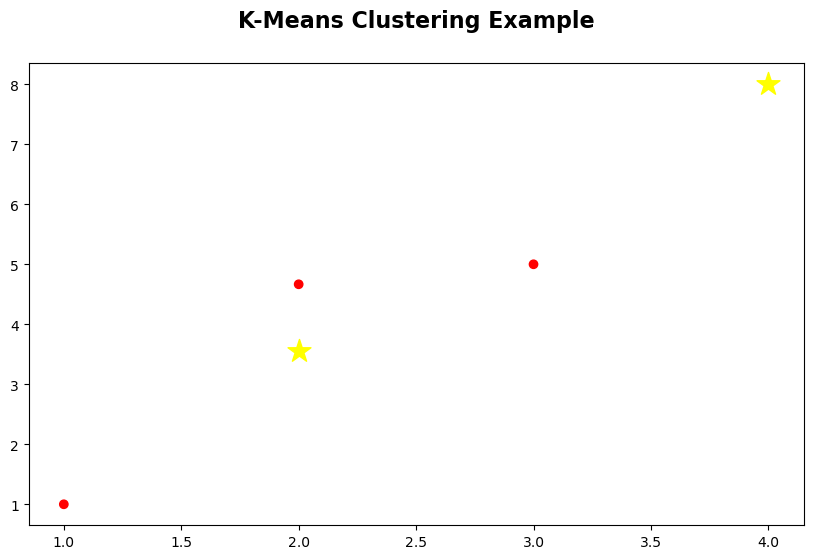



--------------------------------------------------------------------------------------------------------------

			******************** Final Evaluation *********************

            The K-Means model successfully grouped the data into two distinct clusters. 
            Most observations belong to Cluster 0, while one observation forms a separate cluster, 
            indicating a noticeable difference in feature values. The centroids clearly represent the 
            average position of each cluster in the feature space.



In [7]:
"""
    The model effectively separated the data into two meaningful clusters, 
    with one data point showing significant variation from the others.
"""

# Step 6: Visualize Clusters and Centroids
colors = ["red" if label == 0 else "blue" for label in labels]

plt.figure(figsize=(10, 6))

df = df.values

plt.scatter(df[:, 0], df[:, 1], c=colors)
plt.scatter(centroids[:, 0], centroids[:, 1], s=300, c="yellow", marker='*')
plt.title("K-Means Clustering Example", fontsize=16, fontweight="bold", pad=26)
plt.show()

# Final Evaluation
title = " Final Evaluation "
print(f"""\n\n{"-"*110}\n\n{"\t"*3}{title:*^59}\n
            The K-Means model successfully grouped the data into two distinct clusters. 
            Most observations belong to Cluster 0, while one observation forms a separate cluster, 
            indicating a noticeable difference in feature values. The centroids clearly represent the 
            average position of each cluster in the feature space.
""")